In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


In [6]:
import os

print(os.listdir(path))

['PetImages']


In [7]:
import os

pet_path = os.path.join(path, 'PetImages')

print(os.listdir(pet_path))

['Dog', 'Cat']


In [8]:
cats_path = os.path.join(pet_path, 'Cat')
dogs_path = os.path.join(pet_path, 'Dog')

print("Cats images:", len(os.listdir(cats_path)))
print("Dogs images:", len(os.listdir(dogs_path)))

Cats images: 12499
Dogs images: 12499


In [9]:
import cv2
import numpy as np

data = []
labels = []

IMG_SIZE = 64

In [10]:
for img_name in os.listdir(cats_path)[:500]:

    try:
        img_path = os.path.join(cats_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        data.append(img.flatten())

        labels.append(0)

    except:
        pass

In [11]:
for img_name in os.listdir(dogs_path)[:500]:

    try:
        img_path = os.path.join(dogs_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        data.append(img.flatten())

        labels.append(1)

    except:
        pass

In [12]:
X = np.array(data)
y = np.array(labels)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1000, 4096)
Shape of y: (1000,)


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=50)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X.shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (1000, 4096)
Reduced Shape: (1000, 50)


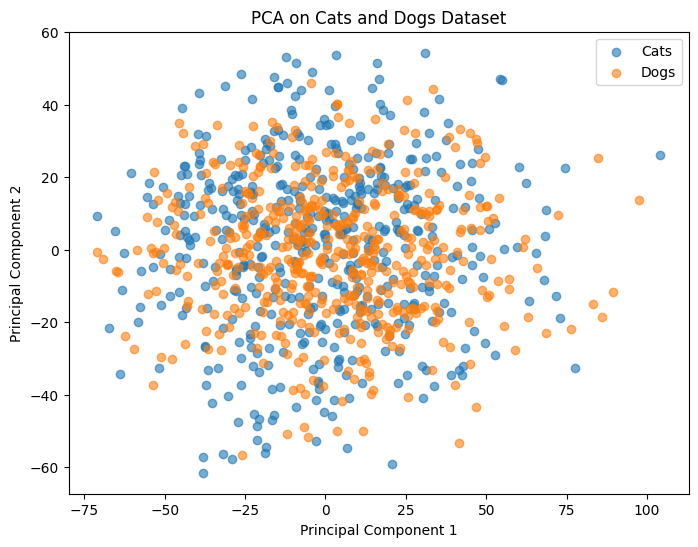

In [14]:
import matplotlib.pyplot as plt

pca_2d = PCA(n_components=2)

X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_2d[y==0, 0],
    X_2d[y==0, 1],
    label='Cats',
    alpha=0.6
)

plt.scatter(
    X_2d[y==1, 0],
    X_2d[y==1, 1],
    label='Dogs',
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Cats and Dogs Dataset")

plt.legend()
plt.show()